In [60]:
import pandas as pd
import seaborn as sns
import numpy as np

In [33]:
df = pd.read_excel("Data_Train.xlsx")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [34]:
df.isna().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [35]:
df.dropna(inplace=True)

In [36]:
df['Date_of_Journey']=pd.to_datetime(df['Date_of_Journey'],format='%d/%m/%Y')

In [37]:
df['Day']=df['Date_of_Journey'].dt.day
df['Month']=df['Date_of_Journey'].dt.month
df['Year']=df['Date_of_Journey'].dt.year

In [38]:
df.drop('Date_of_Journey',axis=1,inplace=True)

In [39]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


In [40]:
df['Dep_Hour'] = df['Dep_Time'].str.split(':').str[0].astype(int)
df['Dep_Min'] = df['Dep_Time'].str.split(':').str[1].astype(int)

In [41]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hour,Dep_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019,16,50


In [42]:
df.drop('Dep_Time', inplace=True , axis=1)

In [43]:
df['Arrival_Time'] = df['Arrival_Time'].str.split(' ').str[0] 

In [44]:
df['Arrival_Hours'] =  df['Arrival_Time'].str.split(':').str[0]
df['Arrival_Min'] = df['Arrival_Time'].str.split(':').str[1]

In [45]:
df.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hour,Dep_Min,Arrival_Hours,Arrival_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10,2h 50m,non-stop,No info,3897,24,3,2019,22,20,01,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25,19h,2 stops,No info,13882,9,6,2019,9,25,04,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,2019,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,2019,16,50,21,35


In [ ]:
df['Duration'] = df['Duration'].str.split(

In [46]:
df['Total_Stops'].unique()


array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [49]:
df['Total_Stops'].replace({'non-stop':0 , '1 stop':1 , '2 stops' : 2 , '3 stops': 3 , '4 stops': 4} , inplace=True)


C:\Users\SriHarshaK\AppData\Local\Temp\ipykernel_23612\910965122.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Total_Stops'].replace({'non-stop':0 , '1 stop':1 , '2 stops' : 2 , '3 stops': 3 , '4 stops': 4} , inplace=True)


In [50]:
df.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hour,Dep_Min,Arrival_Hours,Arrival_Min
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10,2h 50m,0,No info,3897,24,3,2019,22,20,01,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2,No info,7662,1,5,2019,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25,19h,2,No info,13882,9,6,2019,9,25,04,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1,No info,6218,12,5,2019,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1,No info,13302,1,3,2019,16,50,21,35


In [51]:
# Extract hours - handle cases like "2h 30m" or "2h" or "30m"
df['Duration_Hour'] = df['Duration'].str.extract(r'(\d+)h').fillna(0).astype(int)
df['Duration_minute'] = df['Duration'].str.extract(r'(\d+)m').fillna(0).astype(int)

df[['Duration', 'Duration_Hour', 'Duration_minute']].head(10)

,Duration,Duration_Hour,Duration_minute
0,2h 50m,2,50
1,7h 25m,7,25
2,19h,19,0
3,5h 25m,5,25
4,4h 45m,4,45
5,2h 25m,2,25
6,15h 30m,15,30
7,21h 5m,21,5
8,25h 30m,25,30
9,7h 50m,7,50


In [52]:
df.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Hour,Dep_Min,Arrival_Hours,Arrival_Min,Duration_Hour,Duration_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10,2h 50m,0,No info,3897,24,3,2019,22,20,01,10,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2,No info,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25,19h,2,No info,13882,9,6,2019,9,25,04,25,19,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1,No info,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1,No info,13302,1,3,2019,16,50,21,35,4,45


In [55]:
df['Route1']=df['Route'].str.split('→').str[0]
df['Route2']=df['Route'].str.split('→').str[1]
df['Route3']=df['Route'].str.split('→').str[2]
df['Route4']=df['Route'].str.split('→').str[3]
df['Route5']=df['Route'].str.split('→').str[4]

In [66]:
df['Route1'] = df['Route1'].replace({np.nan: 0})
df['Route2'] = df['Route2'].replace({np.nan: 0})
df['Route3'] = df['Route3'].replace({np.nan: 0})
df['Route4'] = df['Route4'].replace({np.nan: 0})
df['Route5'] = df['Route5'].replace({np.nan: 0})

In [67]:
df.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,...,Dep_Min,Arrival_Hours,Arrival_Min,Duration_Hour,Duration_minute,Route1,Route2,Route3,Route4,Route5
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10,2h 50m,0,No info,3897,24,...,20,01,10,2,50,BLR,DEL,0,0,0
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2,No info,7662,1,...,50,13,15,7,25,CCU,IXR,BBI,BLR,0
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25,19h,2,No info,13882,9,...,25,04,25,19,0,DEL,LKO,BOM,COK,0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1,No info,6218,12,...,5,23,30,5,25,CCU,NAG,BLR,0,0
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1,No info,13302,1,...,50,21,35,4,45,BLR,NAG,DEL,0,0


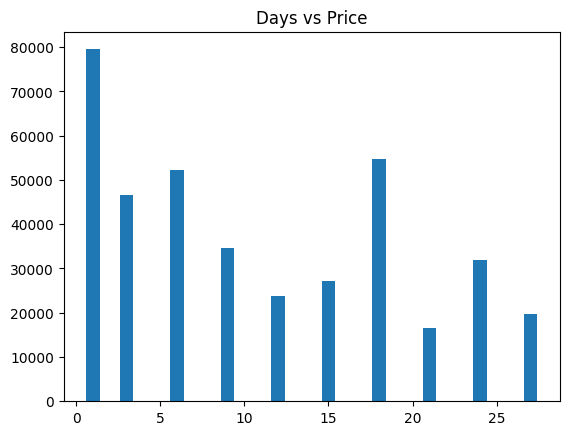

In [84]:
## Step 4 : EDA 
import matplotlib.pyplot as plt

plt.bar(df['Day'] , df['Price'])
plt.title("Days vs Price")
plt.show()

In [85]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Arrival_Time', 'Duration',
       'Total_Stops', 'Additional_Info', 'Price', 'Day', 'Month', 'Year',
       'Dep_Hour', 'Dep_Min', 'Arrival_Hours', 'Arrival_Min', 'Duration_Hour',
       'Duration_minute', 'Route1', 'Route2', 'Route3', 'Route4', 'Route5'],
      dtype='object')

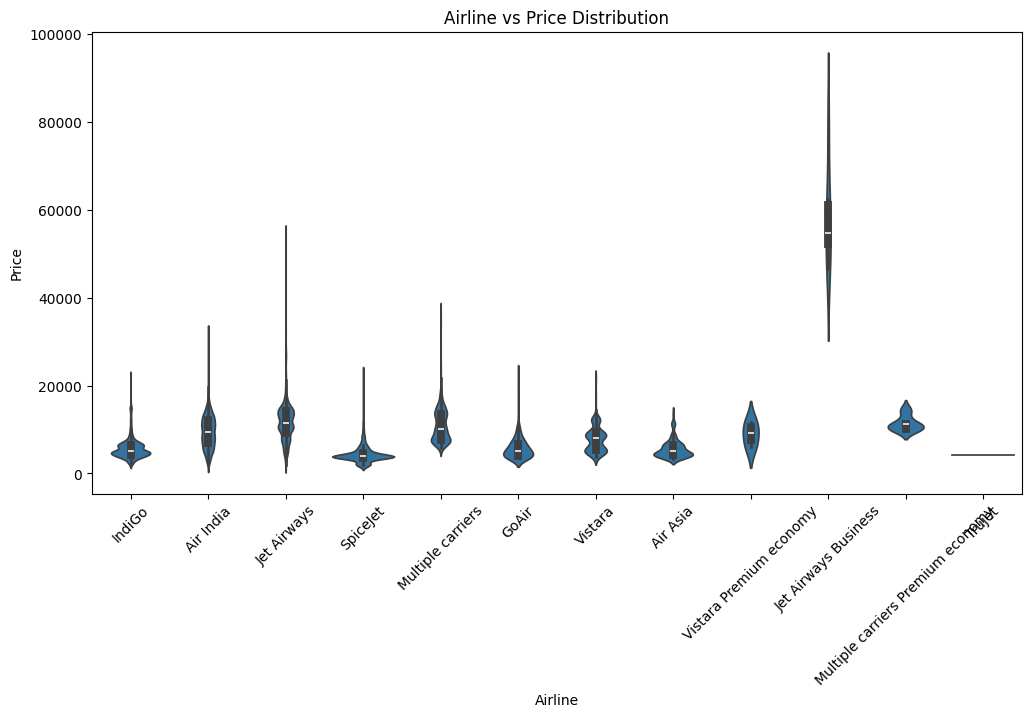

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.violinplot(x='Airline', y='Price', data=df)
plt.xticks(rotation=45)

plt.title("Airline vs Price Distribution")
plt.show()

In [ ]:
import 